# Netflix Data Cleaning and Analysis

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

# Loading uncleaned Data

In [2]:
df = pd.read_csv('C:/Dataset/netflix_titles.csv')

# Metadata

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.notna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,True,True,True,True,False,True,True,True,True,True,True,True
1,True,True,True,False,True,True,True,True,True,True,True,True
2,True,True,True,True,True,False,True,True,True,True,True,True
3,True,True,True,False,False,False,True,True,True,True,True,True
4,True,True,True,False,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,True,True,True,True,True,True,True,True,True,True,True,True
8803,True,True,True,False,False,False,True,True,True,True,True,True
8804,True,True,True,True,True,True,True,True,True,True,True,True
8805,True,True,True,True,True,True,True,True,True,True,True,True


## Checking for Null Values

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

# Handling Missing Data

In [32]:
# filling director column
df["director"] = df["director"].fillna("unknown")

# filling country column
df["country"] = df["country"].fillna("unknown")

# filling cast column
df["cast"] = df["cast"].fillna("Not Available")

# filling date column
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

# filling rating column
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df = df.dropna(subset=["duration"])

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,Not Available,unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Fix Mixed-type Columns

In [34]:
#seperating duration column into duration type and duration value
df[["duration_value", "duration_type"]] = (
    df["duration"].str.extract(r'(\d+)\s+(\w+)')
)

In [35]:
# converting duration_value into integer
df["duration_value"] = df["duration_value"].astype(int)

In [26]:
df["duration_type"] = df["duration_type"].replace({
    "min":"minutes", 
    "Season":"Seasons", 
    "Seasons":"Seasons"
})

In [33]:
# fixing date_time format
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [30]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,minutes
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Seasons
3,s4,TV Show,Jailbirds New Orleans,unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Seasons
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


# Create Cleaned CSV Data

In [31]:
df.to_csv('cleaned_netflix-data.csv')

#  Visualization

### 1. What content type dominates Netflix?

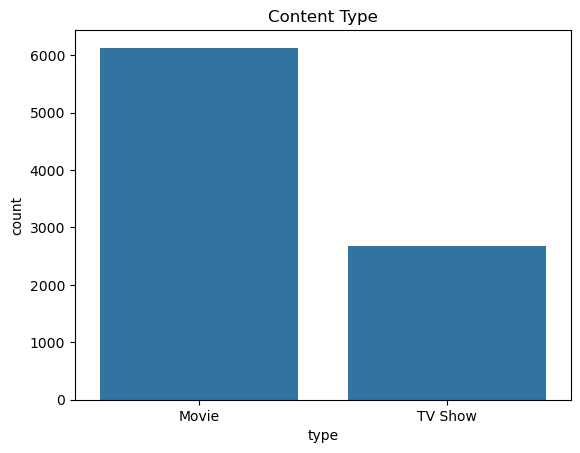

In [38]:
sns.countplot(x='type',data=df,) 
plt.title("Content Type")
plt.show()

### 2. Which countries produce the highest Netflix content?

In [39]:
df['country'].value_counts().head(10)

country
United States     2815
India              972
unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

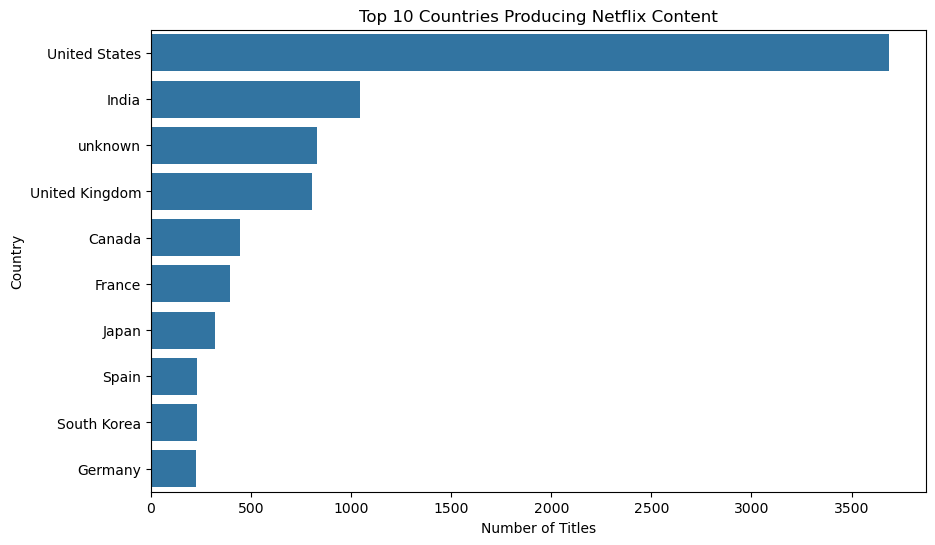

In [41]:
country_count = (
    df['country']
    .dropna()
    .str.split(',')
    .explode()       # explod() Converts list items into separate rows.
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

 ### 3. What is the average runtime of Netflix movies?

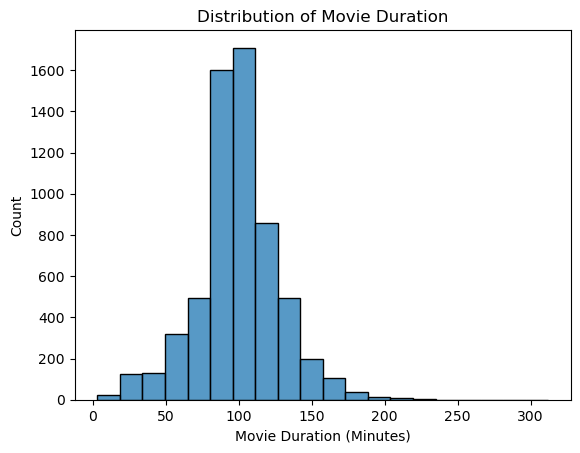

In [46]:
df = pd.read_csv('cleaned_netflix-data.csv')

movies = df[df['duration_type']=="minutes"]

sns.histplot(
movies['duration_value'],
bins=20
)
plt.title("Distribution of Movie Duration")
plt.xlabel("Movie Duration (Minutes)")
plt.ylabel("Count")

plt.show()

 ### 4. Which ratings are most common?

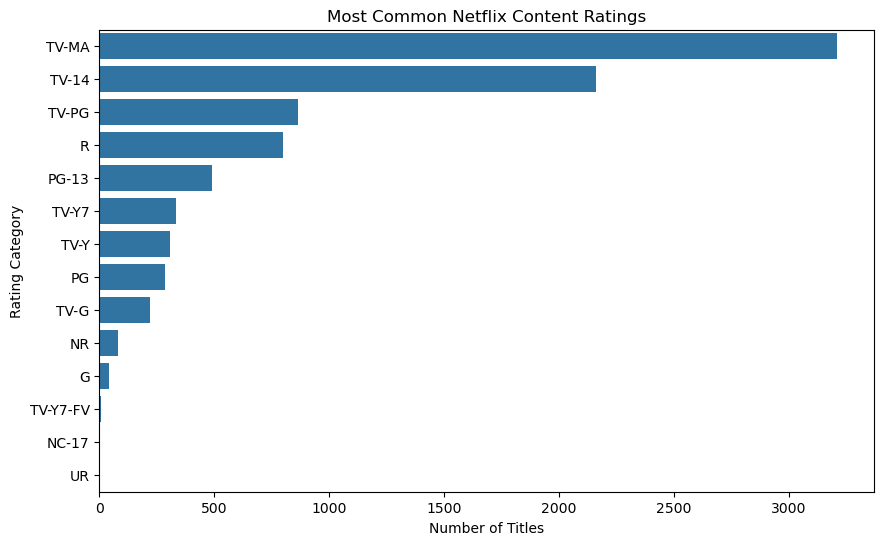

In [51]:
plt.figure(figsize=(10,6))

rating_order = df['rating'].value_counts().index

sns.countplot(
    y='rating',
    data=df,
    order=rating_order
)

plt.title("Most Common Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating Category")

plt.show()

 ### 5. Which genres dominate Netflix?

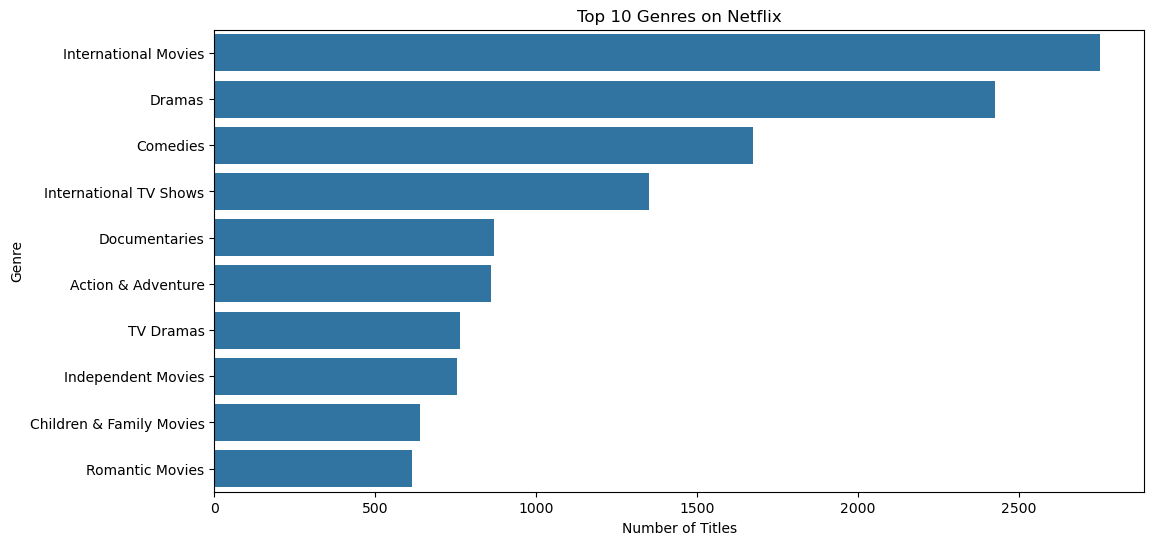

In [54]:
genres = (df["listed_in"]
          .dropna()
          .str.split(",")
          .explode()
          .str.strip()
         )
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

 ### 6. Who are Netflix's top content creators?

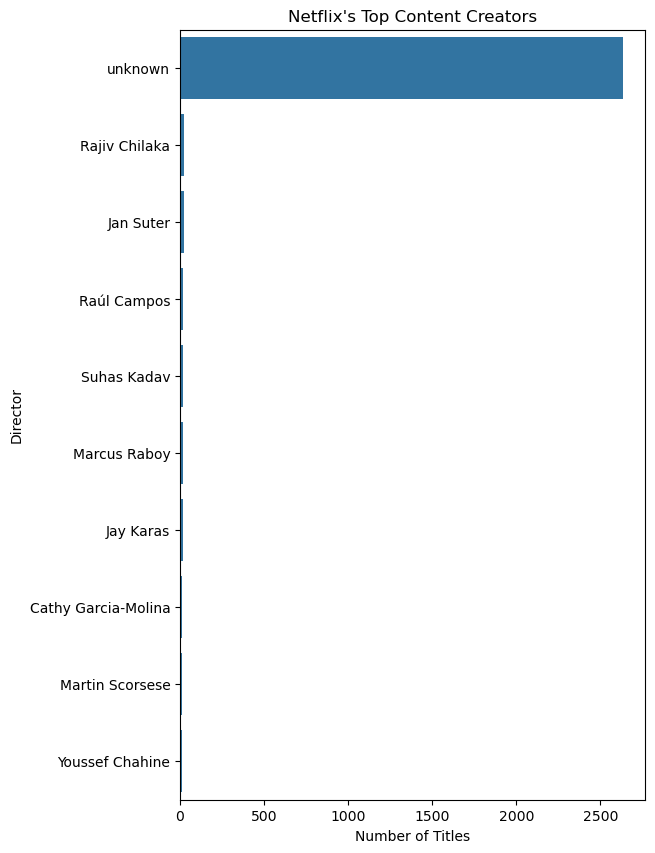

In [64]:
creators = (df['director']
            .dropna()
            .str.split(",")
            .explode()
            .str.strip()
           )
top_creators = creators.value_counts().head(10)

plt.figure(figsize=(6,10))

sns.barplot(
    x=top_creators.values,
    y=top_creators.index
)

plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.title("Netflix's Top Content Creators")

plt.show()